A ROC Curve (Receiver Operating Characteristic Curve) is a core evaluation tool for binary classification models (like Logistic Regression). It helps you understand how well your model separates the two classes across all possible thresholds.

🔷 1. What ROC Curve Represents

At its core, ROC plots:

X-axis → False Positive Rate (FPR)
Y-axis → True Positive Rate (TPR / Recall / Sensitivity)
🔹 Key Formulas

TPR=
TP+FN
TP
	​


FPR=
FP+TN
FP
	​


🔹 Meaning
TPR (Recall) → How many actual positives you correctly identified
FPR → How many negatives you incorrectly labeled as positive
🔷 2. Why ROC Curve is Needed

In models like Logistic Regression, you get probabilities, not labels:

P(y = 1 | x) = 0.73

To convert this into a class:

You choose a threshold (default = 0.5)

But different thresholds → different predictions.

👉 ROC shows performance across ALL thresholds (0 → 1)

🔷 3. How ROC Curve is Constructed

Step-by-step:

Sort predicted probabilities (descending)
For each threshold:
Convert probabilities → class labels
Compute TPR & FPR
Plot (FPR, TPR)
🔷 4. Interpreting the Curve
🔹 Ideal Model
Goes top-left corner (TPR=1, FPR=0)
🔹 Random Model
Diagonal line:
TPR=FPR
🔹 Good Model
Curve bows toward top-left
🔷 5. AUC (Area Under Curve)

0≤AUC≤1

Meaning:
AUC = 1 → Perfect model
AUC = 0.5 → Random guessing
AUC < 0.5 → Worse than random
🔹 Intuition

AUC = Probability that:

Model ranks a random positive higher than a random negative

🔷 6. Threshold Trade-off
Threshold	TPR	FPR	Meaning
High (0.9)	Low	Very Low	Conservative
Medium (0.5)	Balanced	Balanced	Default
Low (0.1)	High	High	Aggressive

👉 This is Bias–Variance-like tradeoff in classification

🔷 7. ROC vs Precision-Recall
ROC	Precision-Recall
Good for balanced data	Better for imbalanced data
Uses TN	Ignores TN

👉 If your dataset is imbalanced → prefer PR curve

🔷 8. sklearn Implementation
🔹 Basic Code
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_true = actual labels
# y_prob = predicted probabilities

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
🔷 9. Logistic Regression Example
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = LogisticRegression()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

Then plug into ROC code above.

🔷 10. Practical Insights (VERY IMPORTANT)
✔ When to use ROC:
Comparing multiple models
Binary classification
Balanced dataset
❌ Common Mistakes:

Using predicted labels instead of probabilities

# WRONG
roc_curve(y_test, y_pred)
Ignoring class imbalance
Thinking AUC = accuracy (it's NOT)
🔷 11. Intuition in One Line

👉 ROC answers:

“How well can my model distinguish between positive and negative classes across all thresholds?”

🔷 12. Visual Summary (Mental Model)
Move threshold ↓
→ TPR ↑ but FPR ↑
Move threshold ↑
→ TPR ↓ but FPR ↓

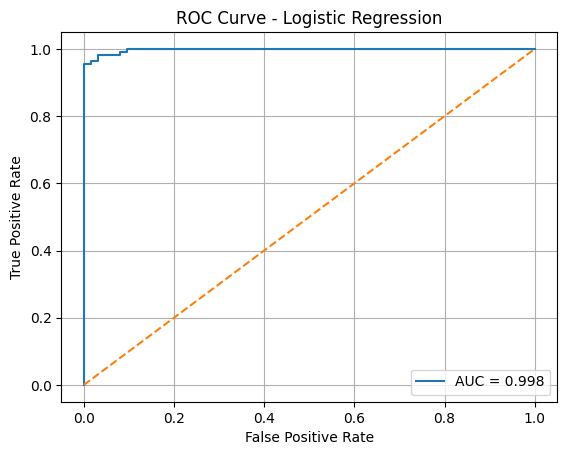

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# 1. Load real dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Train Logistic Regression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# 4. Get probabilities (IMPORTANT)
y_prob = model.predict_proba(X_test)[:, 1]

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 6. Compute AUC
roc_auc = auc(fpr, tpr)

# 7. Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()

plt.show()

### 4. How to Read This Graph
1. Blue curve (model) → your classifier
2. Diagonal line → random guessing
Key insights:
1. Curve closer to top-left → better model
2. Large gap between curve & diagonal → strong classifier
3. Area under curve (AUC) ≈ 0.95+ (typical for this dataset)

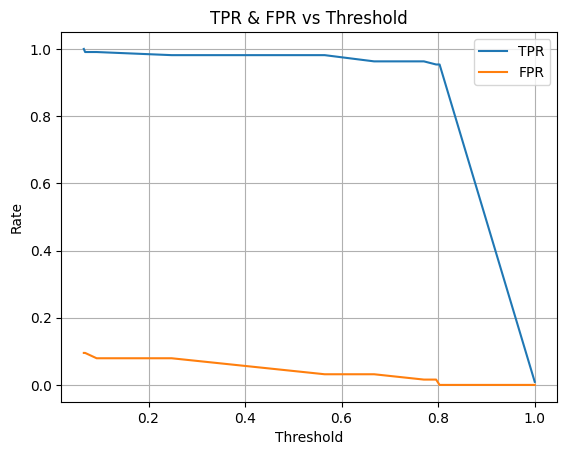

In [9]:
plt.figure()

plt.plot(thresholds[:-1], tpr[:-1], label="TPR")
plt.plot(thresholds[:-1], fpr[:-1], label="FPR")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TPR & FPR vs Threshold")
plt.legend()
plt.grid()

plt.show()